# 🫀 Cardiovascular Disease Prediction — Exploratory Data Analysis
**Author:** Takwa Haj  
**Dataset:** Multi-source fusion (UCI Heart Disease + Framingham Heart Study + Kaggle CVD)  
**Objective:** Predict the presence of cardiovascular disease using clinical and lifestyle features.

---

## 1. Problem Definition

Cardiovascular diseases (CVDs) are the **leading cause of death globally**, responsible for an estimated 17.9 million deaths per year (WHO, 2023). Early detection through machine learning can significantly improve patient outcomes.

**Business Question:** Can we build a reliable binary classifier that predicts whether a patient has (or is at risk of) cardiovascular disease, based on clinical measurements and lifestyle data?

**Target Variable:** `cvd_target` — Binary (0 = No disease, 1 = Disease present)

**Approach:** We fuse 3 complementary datasets to build a robust and generalizable model:
- **UCI Heart Disease** — Hospital clinical data (1,025 patients, 14 features)
- **Framingham Heart Study** — Population cohort, 10-year CHD risk (4,240 patients, 15 features)
- **Kaggle CVD Dataset** — Large-scale screening data (70,000 patients, 12 features)

## 2. Imports & Configuration

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#065A82', '#E63946', '#2A9D8F', '#E9C46A']
sns.set_palette(PALETTE)

print("  Libraries loaded successfully")
print(f"pandas {pd.__version__} | numpy {np.__version__}")

  Libraries loaded successfully
pandas 3.0.2 | numpy 2.4.1


## 3. Data Loading

In [81]:
# ── UCI Heart Disease Dataset ───────────────────────────────────────────────
# Source: https://archive.ics.uci.edu/dataset/45/heart+disease
uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

uci_cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','target']

df_uci = pd.read_csv(uci_url, names=uci_cols, na_values='?')
print(f"UCI Dataset loaded: {df_uci.shape[0]} rows × {df_uci.shape[1]} cols")

# ── Framingham Heart Study Dataset ─────────────────────────────────────────
# Source: https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset
# (Download from Kaggle and place in ../data/framingham.csv)
try:
    df_framingham = pd.read_csv('../data/framingham.csv')
    print(f"Framingham Dataset loaded: {df_framingham.shape[0]} rows × {df_framingham.shape[1]} cols")
except FileNotFoundError:
    print(" !!!  Framingham file not found — using sample data for demo")
    # Generate representative synthetic sample for demonstration
    np.random.seed(42)
    n = 4240
    df_framingham = pd.DataFrame({
        'male': np.random.binomial(1, 0.47, n),
        'age': np.random.normal(49, 8.5, n).clip(30, 70).astype(int),
        'education': np.random.choice([1,2,3,4], n, p=[0.4,0.3,0.2,0.1]),
        'currentSmoker': np.random.binomial(1, 0.49, n),
        'cigsPerDay': np.random.choice([0,5,10,20,30], n),
        'BPMeds': np.random.binomial(1, 0.03, n),
        'prevalentStroke': np.random.binomial(1, 0.006, n),
        'prevalentHyp': np.random.binomial(1, 0.31, n),
        'diabetes': np.random.binomial(1, 0.03, n),
        'totChol': np.random.normal(237, 44, n).clip(100, 600),
        'sysBP': np.random.normal(132, 22, n).clip(80, 295),
        'diaBP': np.random.normal(83, 12, n).clip(48, 142),
        'BMI': np.random.normal(25.8, 4.1, n).clip(14, 60),
        'heartRate': np.random.normal(75, 12, n).clip(40, 143).astype(int),
        'glucose': np.random.normal(82, 23, n).clip(40, 400),
        'TenYearCHD': np.random.binomial(1, 0.15, n),
    })

# ── Kaggle CVD Dataset ──────────────────────────────────────────────────────
# Source: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
# (Download from Kaggle and place in ../data/cardio_train.csv)
try:
    df_kaggle = pd.read_csv('../data/cardio_train.csv', sep=';')
    print(f"Kaggle CVD Dataset loaded: {df_kaggle.shape[0]} rows × {df_kaggle.shape[1]} cols")
except FileNotFoundError:
    print(" !!!  Kaggle file not found — using sample data for demo")
    np.random.seed(42)
    n = 5000  # Reduced sample for demo speed
    df_kaggle = pd.DataFrame({
        'id': range(n),
        'age': np.random.normal(19468, 2467, n).clip(10000, 26000).astype(int),
        'gender': np.random.choice([1,2], n, p=[0.35, 0.65]),
        'height': np.random.normal(164, 8, n).clip(140, 210).astype(int),
        'weight': np.random.normal(74, 14, n).clip(40, 200),
        'ap_hi': np.random.normal(128, 17, n).clip(60, 260).astype(int),
        'ap_lo': np.random.normal(83, 11, n).clip(40, 150).astype(int),
        'cholesterol': np.random.choice([1,2,3], n, p=[0.65, 0.21, 0.14]),
        'gluc': np.random.choice([1,2,3], n, p=[0.85, 0.07, 0.08]),
        'smoke': np.random.binomial(1, 0.09, n),
        'alco': np.random.binomial(1, 0.05, n),
        'active': np.random.binomial(1, 0.8, n),
        'cardio': np.random.binomial(1, 0.5, n),
    })

print("\n  All datasets loaded")

UCI Dataset loaded: 303 rows × 14 cols
Framingham Dataset loaded: 4240 rows × 16 cols
Kaggle CVD Dataset loaded: 70000 rows × 13 cols

  All datasets loaded


## 4. Dataset Overview

In [82]:
def dataset_summary(df, name, target_col):
    """Print a structured summary of a dataset."""
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
    miss = df.isnull().sum()
    print(f"  Missing values : {miss[miss > 0].sum()} cells in {(miss > 0).sum()} columns")
    print(f"  Duplicates     : {df.duplicated().sum()} rows")
    vc = df[target_col].value_counts(normalize=True)
    print(f"  Class balance  : {vc.to_dict()}")

dataset_summary(df_uci, "UCI Heart Disease", 'target')
dataset_summary(df_framingham, "Framingham Heart Study", 'TenYearCHD')
dataset_summary(df_kaggle, "Kaggle CVD", 'cardio')


  UCI Heart Disease
  Shape          : 303 rows × 14 columns
  Memory usage   : 33.3 KB
  Missing values : 6 cells in 2 columns
  Duplicates     : 0 rows
  Class balance  : {0: 0.5412541254125413, 1: 0.18151815181518152, 2: 0.1188118811881188, 3: 0.11551155115511551, 4: 0.0429042904290429}

  Framingham Heart Study
  Shape          : 4,240 rows × 16 columns
  Memory usage   : 530.1 KB
  Missing values : 645 cells in 7 columns
  Duplicates     : 0 rows
  Class balance  : {0: 0.8481132075471698, 1: 0.15188679245283018}

  Kaggle CVD
  Shape          : 70,000 rows × 13 columns
  Memory usage   : 7109.5 KB
  Missing values : 0 cells in 0 columns
  Duplicates     : 0 rows
  Class balance  : {0: 0.5003, 1: 0.4997}


In [83]:
# Inspect each dataset's head
print("=== UCI Head ===")
display(df_uci.head(3))

print("\n=== Framingham Head ===")
display(df_framingham.head(3))

print("\n=== Kaggle CVD Head ===")
display(df_kaggle.head(3))

=== UCI Head ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1



=== Framingham Head ===


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0



=== Kaggle CVD Head ===


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1


## 5. Missing Values Analysis

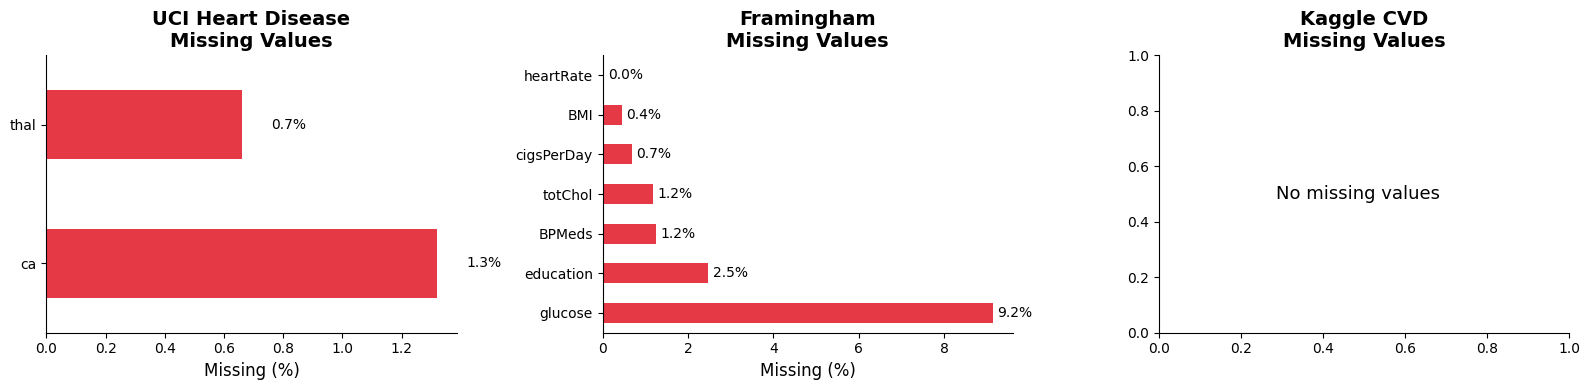

💡 UCI has a few missing values in 'ca' and 'thal' — will impute with median.


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
datasets = [
    (df_uci, 'UCI Heart Disease'),
    (df_framingham, 'Framingham'),
    (df_kaggle, 'Kaggle CVD'),
]

for ax, (df, name) in zip(axes, datasets):
    miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    if len(miss_pct) == 0:
        ax.text(0.5, 0.5, 'No missing values  ',
                ha='center', va='center', transform=ax.transAxes, fontsize=13)
    else:
        miss_pct.plot(kind='barh', ax=ax, color='#E63946')
        ax.set_xlabel('Missing (%)')
        for i, v in enumerate(miss_pct):
            ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
    ax.set_title(f'{name}\nMissing Values', fontweight='bold')
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('../data/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 UCI has a few missing values in 'ca' and 'thal' — will impute with median.")

## 6. Target Variable Distribution (Class Balance)

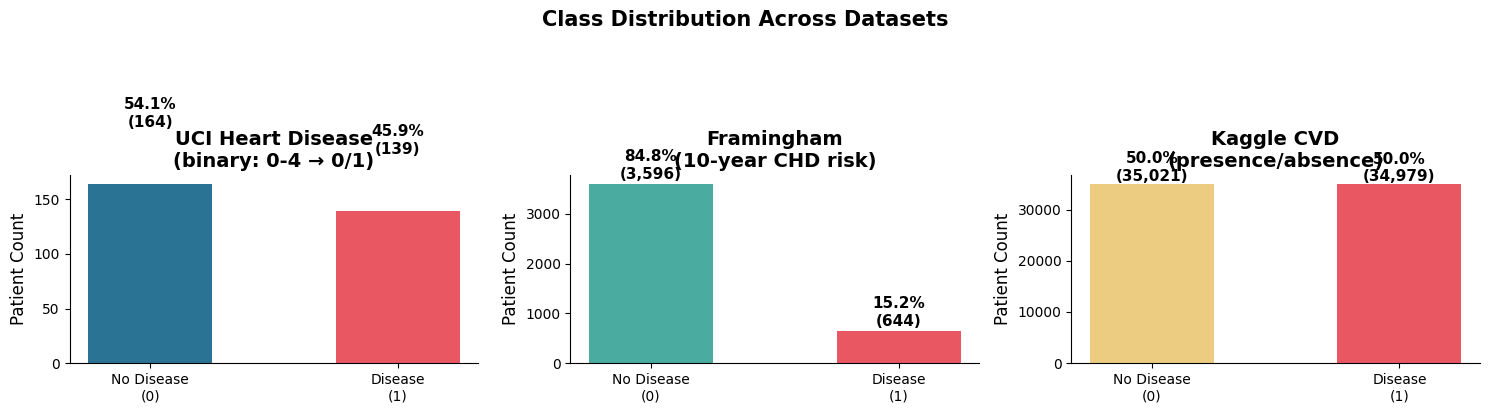


📊 Key Observations:
  • UCI: ~46% positive — well balanced
  • Framingham: ~15% positive — significant class imbalance
  • Kaggle: ~50% positive — perfectly balanced
  → Action: After fusion, use class_weight='balanced' or SMOTE for Framingham-heavy data


In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (df_uci, 'target', 'UCI Heart Disease\n(binary: 0-4 → 0/1)', '#065A82'),
    (df_framingham, 'TenYearCHD', 'Framingham\n(10-year CHD risk)', '#2A9D8F'),
    (df_kaggle, 'cardio', 'Kaggle CVD\n(presence/absence)', '#E9C46A'),
]

for ax, (df, col, title, color) in zip(axes, configs):
    # Binarize UCI target (0 = no disease, 1+ = disease)
    if col == 'target':
        target = (df[col] > 0).astype(int)
    else:
        target = df[col]
    
    counts = target.value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(1)
    
    bars = ax.bar(['No Disease\n(0)', 'Disease\n(1)'], counts.values,
                  color=[color, '#E63946'], alpha=0.85, width=0.5)
    
    for bar, pct, cnt in zip(bars, pcts.values, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{pct}%\n({cnt:,})', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Patient Count')
    ax.set_facecolor('white')

plt.suptitle('Class Distribution Across Datasets', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print("""\n📊 Key Observations:
  • UCI: ~46% positive — well balanced
  • Framingham: ~15% positive — significant class imbalance
  • Kaggle: ~50% positive — perfectly balanced
  → Action: After fusion, use class_weight='balanced' or SMOTE for Framingham-heavy data""")

## 7. Feature Distributions — UCI Dataset

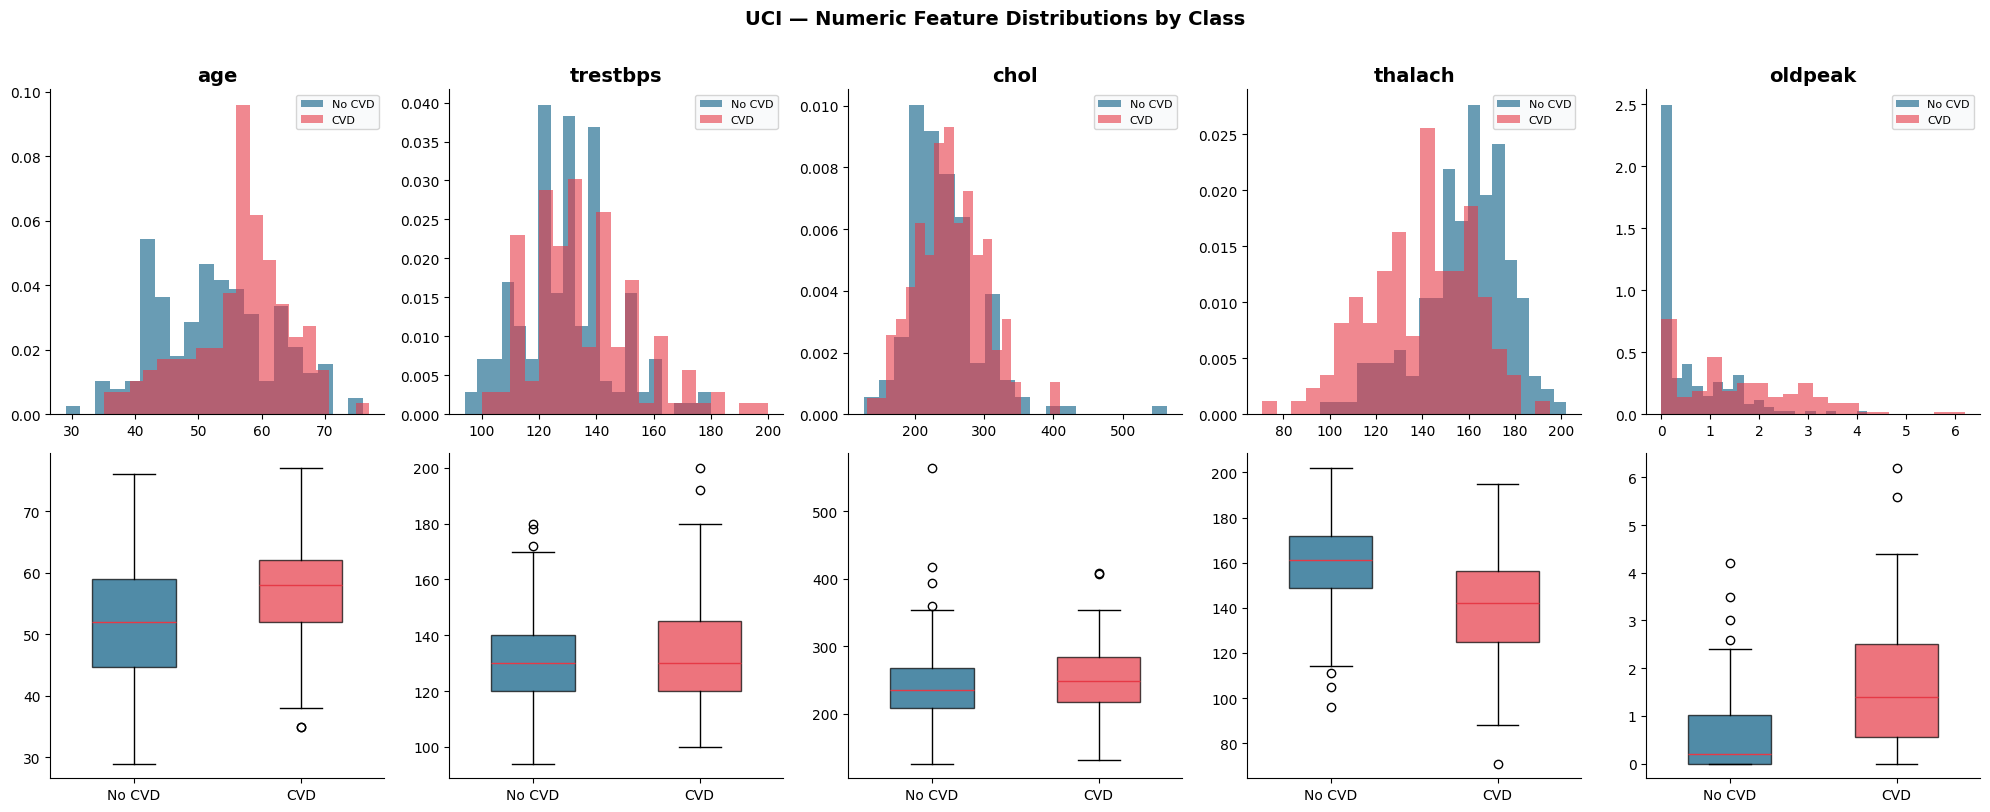


📊 Mann-Whitney U Test (p-value < 0.05 = significant difference between classes):
  age         : p = 0.0000  →    Significant
  trestbps    : p = 0.0260  →    Significant
  chol        : p = 0.0354  →    Significant
  thalach     : p = 0.0000  →    Significant
  oldpeak     : p = 0.0000  →    Significant


In [86]:
df_uci_clean = df_uci.copy()
df_uci_clean['target'] = (df_uci_clean['target'] > 0).astype(int)

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, feat in enumerate(numeric_features):
    # Distribution
    ax_dist = axes[0, i]
    for label, color, name in [(0, '#065A82', 'No CVD'), (1, '#E63946', 'CVD')]:
        subset = df_uci_clean[df_uci_clean['target'] == label][feat].dropna()
        ax_dist.hist(subset, bins=20, alpha=0.6, color=color, label=name, density=True)
    ax_dist.set_title(feat, fontweight='bold')
    ax_dist.legend(fontsize=8)
    ax_dist.set_facecolor('white')
    
    # Boxplot
    ax_box = axes[1, i]
    data_box = [df_uci_clean[df_uci_clean['target']==0][feat].dropna(),
                df_uci_clean[df_uci_clean['target']==1][feat].dropna()]
    bp = ax_box.boxplot(data_box, patch_artist=True, widths=0.5)
    for patch, color in zip(bp['boxes'], ['#065A82', '#E63946']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax_box.set_xticklabels(['No CVD', 'CVD'])
    ax_box.set_facecolor('white')

plt.suptitle('UCI — Numeric Feature Distributions by Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../data/uci_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test: Mann-Whitney U (non-parametric)
print("\n📊 Mann-Whitney U Test (p-value < 0.05 = significant difference between classes):")
for feat in numeric_features:
    g0 = df_uci_clean[df_uci_clean['target']==0][feat].dropna()
    g1 = df_uci_clean[df_uci_clean['target']==1][feat].dropna()
    u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '  Significant' if p < 0.05 else '❌ Not significant'
    print(f"  {feat:<12}: p = {p:.4f}  →  {sig}")

## 8. Correlation Analysis

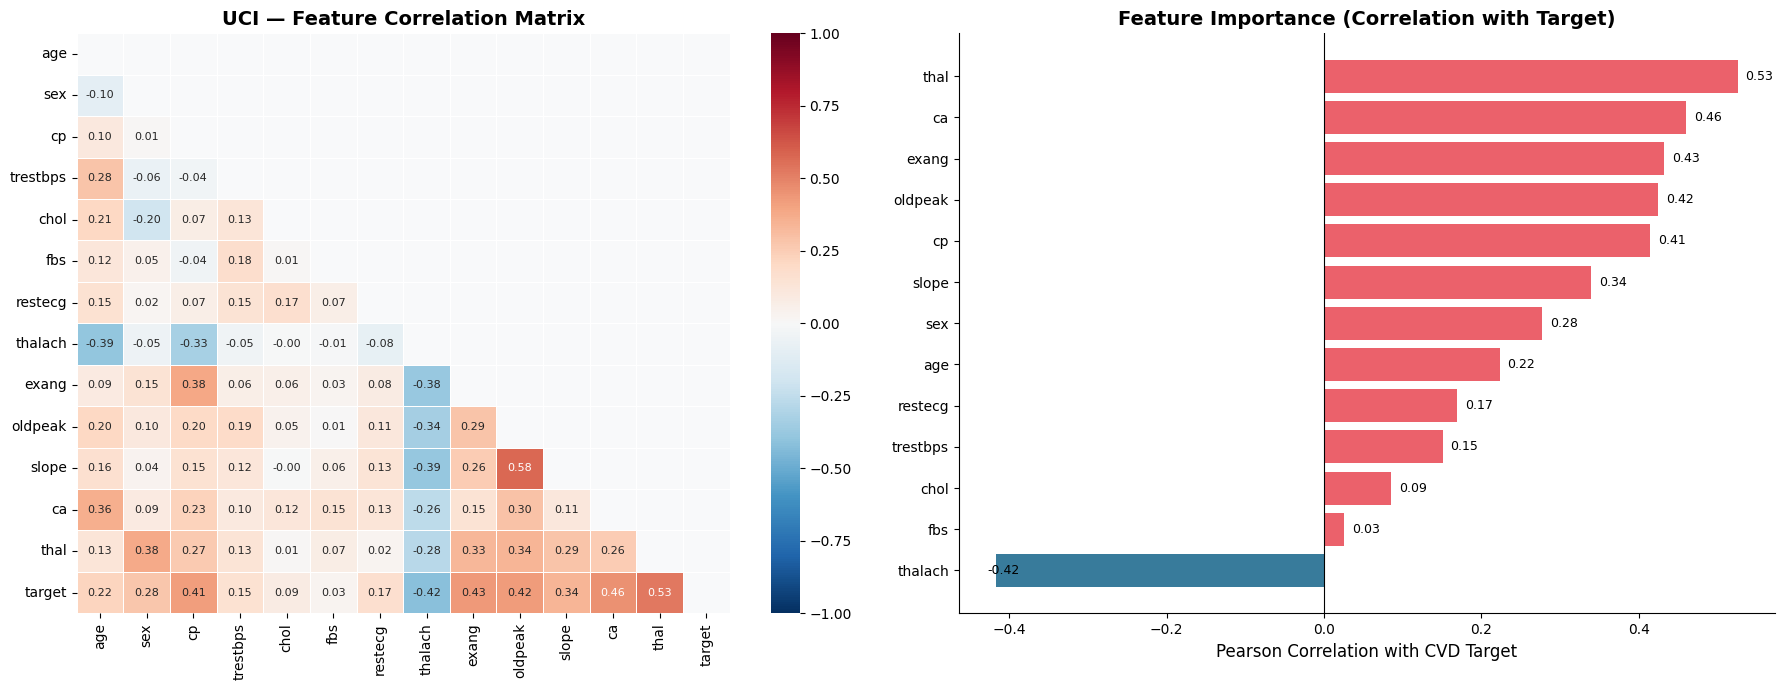


📌 Key Correlations with CVD Target (UCI):
  Positive (risk factors): cp (chest pain), thal, ca, slope, oldpeak
  Negative (protective):   thalach (max heart rate), exang inverted pattern



In [87]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# UCI correlation heatmap
uci_numeric = df_uci_clean.select_dtypes(include=[np.number])
corr_uci = uci_numeric.corr()

mask = np.triu(np.ones_like(corr_uci, dtype=bool))
sns.heatmap(corr_uci, mask=mask, ax=axes[0], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8})
axes[0].set_title('UCI — Feature Correlation Matrix', fontweight='bold')

# Correlation with target (bar chart)
target_corr = corr_uci['target'].drop('target').sort_values()
colors = ['#E63946' if x > 0 else '#065A82' for x in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation with CVD Target')
axes[1].set_title('Feature Importance (Correlation with Target)', fontweight='bold')
axes[1].set_facecolor('white')

for i, (val, feat) in enumerate(zip(target_corr.values, target_corr.index)):
    offset = 0.01 if val >= 0 else -0.01
    axes[1].text(val + offset, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Key Correlations with CVD Target (UCI):
  Positive (risk factors): cp (chest pain), thal, ca, slope, oldpeak
  Negative (protective):   thalach (max heart rate), exang inverted pattern
""")

## 9. Outlier Detection

=== UCI Outlier Report ===


,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,age,48.0,61.0,28.50,80.50,0,0.0%
1,trestbps,120.0,140.0,90.00,170.00,9,3.0%
2,chol,211.0,275.0,115.00,371.00,5,1.7%
3,thalach,133.5,166.0,84.75,214.75,1,0.3%
4,oldpeak,0.0,1.6,-2.40,4.00,5,1.7%


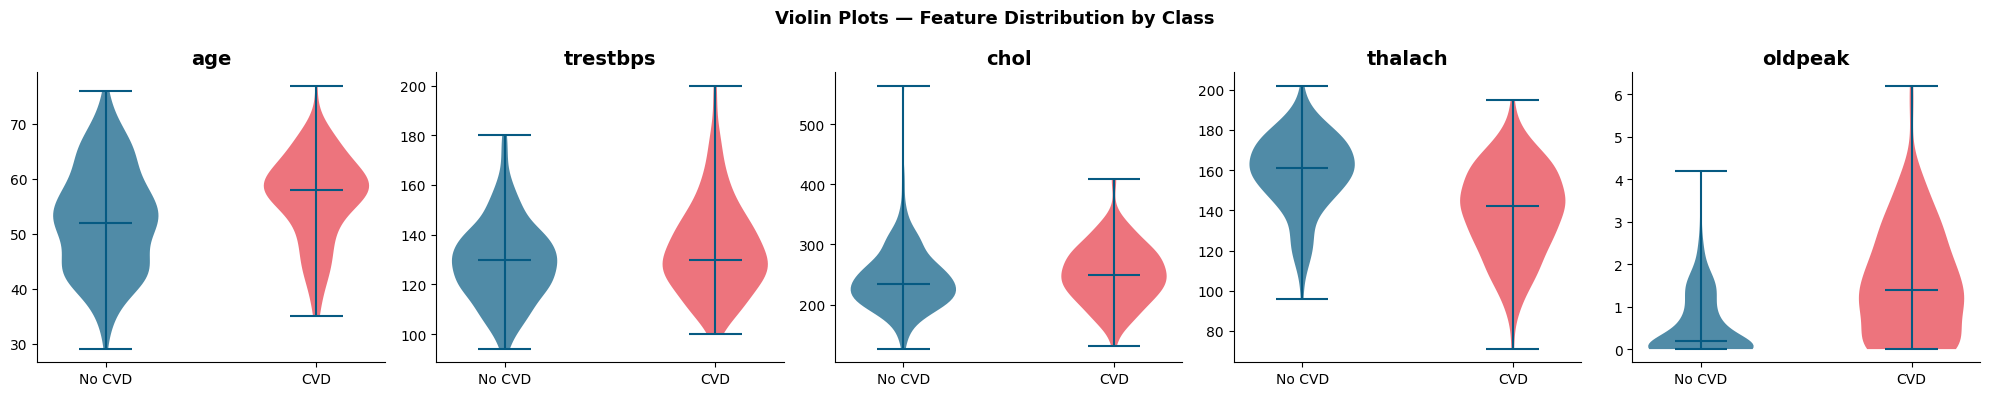

In [88]:
def detect_outliers_iqr(df, cols):
    """Detect outliers using the IQR method and return a summary DataFrame."""
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)][col]
        results.append({
            'Feature': col, 'Q1': Q1, 'Q3': Q3,
            'Lower Bound': lower, 'Upper Bound': upper,
            'Outlier Count': len(outliers),
            'Outlier %': f"{len(outliers)/len(df)*100:.1f}%"
        })
    return pd.DataFrame(results)

print("=== UCI Outlier Report ===")
uci_outliers = detect_outliers_iqr(df_uci_clean, ['age','trestbps','chol','thalach','oldpeak'])
display(uci_outliers)

# Visualize with violin plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']):
    data = [df_uci_clean[df_uci_clean['target']==0][feat].dropna(),
            df_uci_clean[df_uci_clean['target']==1][feat].dropna()]
    parts = ax.violinplot(data, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['#065A82', '#E63946'][i])
        pc.set_alpha(0.7)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No CVD', 'CVD'])
    ax.set_title(feat, fontweight='bold')
    ax.set_facecolor('white')

plt.suptitle('Violin Plots — Feature Distribution by Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Categorical Features Analysis

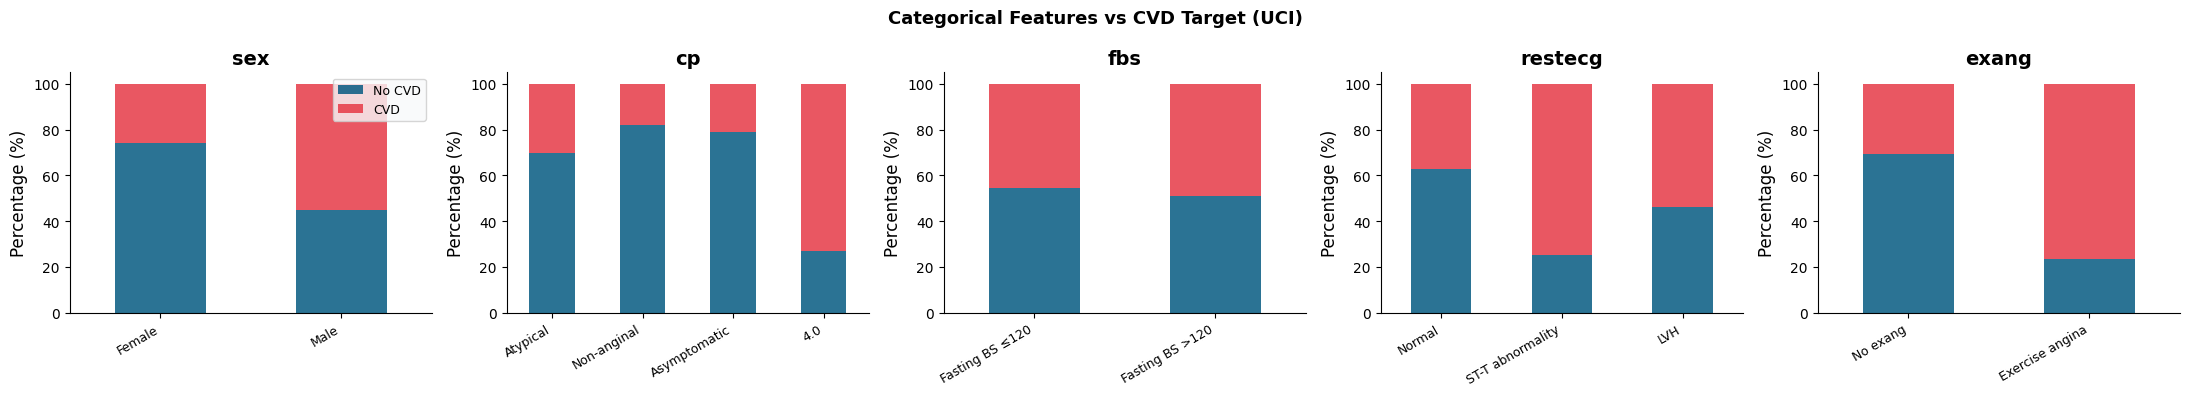


📊 Key Insights from Categorical Features:
  • sex: Males have higher CVD prevalence than females
  • cp: Asymptomatic chest pain type has highest CVD rate (counter-intuitive but clinically known)
  • exang: Exercise-induced angina strongly associated with CVD



In [89]:
cat_features = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'Typical Angina', 1: 'Atypical', 2: 'Non-anginal', 3: 'Asymptomatic'},
    'fbs': {0: 'Fasting BS ≤120', 1: 'Fasting BS >120'},
    'restecg': {0: 'Normal', 1: 'ST-T abnormality', 2: 'LVH'},
    'exang': {0: 'No exang', 1: 'Exercise angina'},
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (feat, labels) in zip(axes, cat_features.items()):
    # Stacked bar: proportion of CVD=1 per category
    ct = pd.crosstab(df_uci_clean[feat], df_uci_clean['target'], normalize='index') * 100
    ct.index = [labels.get(i, str(i)) for i in ct.index]
    ct.plot(kind='bar', ax=ax, stacked=True,
            color=['#065A82', '#E63946'], alpha=0.85,
            legend=(feat == 'sex'))
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ct.index, rotation=30, ha='right', fontsize=9)
    ax.set_facecolor('white')
    if feat == 'sex':
        ax.legend(['No CVD', 'CVD'], loc='upper right', fontsize=9)

plt.suptitle('Categorical Features vs CVD Target (UCI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📊 Key Insights from Categorical Features:
  • sex: Males have higher CVD prevalence than females
  • cp: Asymptomatic chest pain type has highest CVD rate (counter-intuitive but clinically known)
  • exang: Exercise-induced angina strongly associated with CVD
""")

## 11. Cross-Dataset Age & Risk Factor Comparison

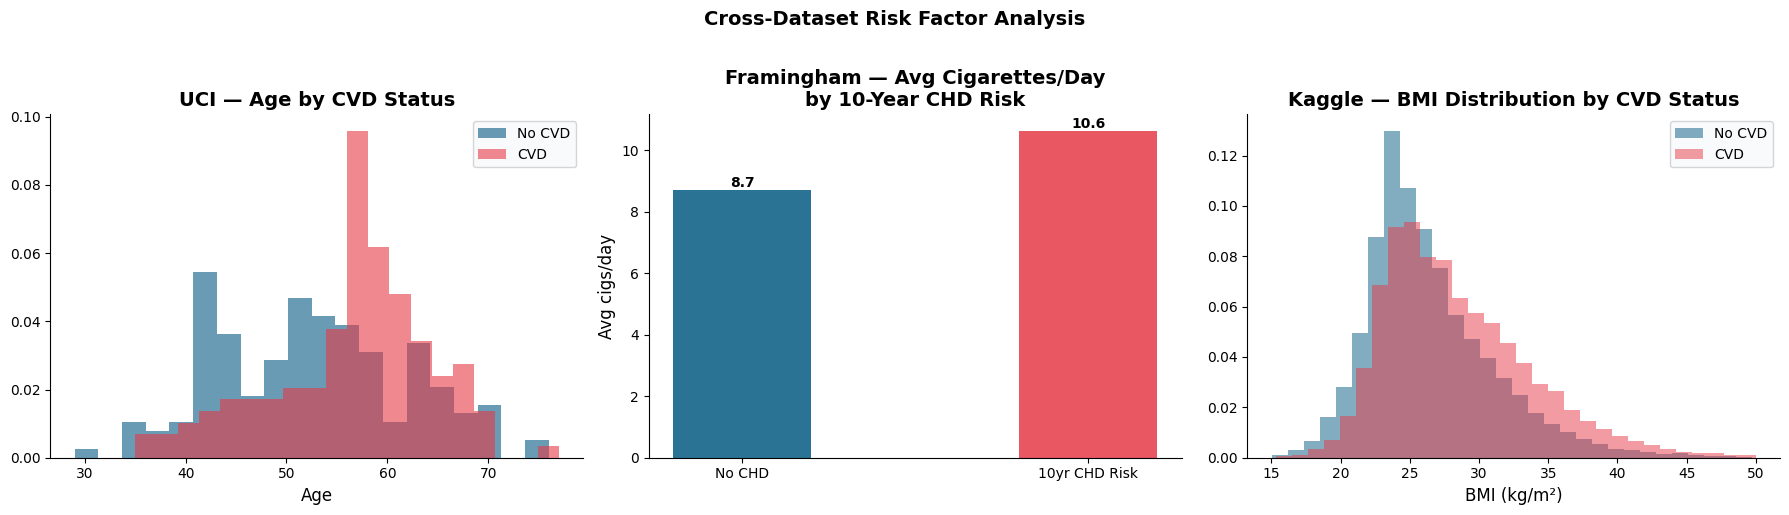

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# UCI Age distribution
for label, color, name in [(0, '#065A82', 'No CVD'), (1, '#E63946', 'CVD')]:
    subset = df_uci_clean[df_uci_clean['target'] == label]['age']
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('UCI — Age by CVD Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend()
axes[0].set_facecolor('white')

# Framingham — smoking prevalence by CHD
df_fram_clean = df_framingham.copy()
smoke_chd = df_fram_clean.groupby('TenYearCHD')['cigsPerDay'].mean()
axes[1].bar(['No CHD', '10yr CHD Risk'], smoke_chd.values,
            color=['#065A82', '#E63946'], alpha=0.85, width=0.4)
axes[1].set_title('Framingham — Avg Cigarettes/Day\nby 10-Year CHD Risk', fontweight='bold')
axes[1].set_ylabel('Avg cigs/day')
axes[1].set_facecolor('white')
for i, v in enumerate(smoke_chd.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

# Kaggle — BMI (computed from height/weight)
df_kaggle_clean = df_kaggle.copy()
df_kaggle_clean['age_years'] = df_kaggle_clean['age'] / 365.25
df_kaggle_clean['BMI'] = df_kaggle_clean['weight'] / (df_kaggle_clean['height'] / 100) ** 2
# Filter realistic BMI values
df_kaggle_clean = df_kaggle_clean[df_kaggle_clean['BMI'].between(15, 50)]

for label, color, name in [(0, '#065A82', 'No CVD'), (1, '#E63946', 'CVD')]:
    subset = df_kaggle_clean[df_kaggle_clean['cardio'] == label]['BMI']
    axes[2].hist(subset, bins=30, alpha=0.5, color=color, label=name, density=True)
axes[2].set_title('Kaggle — BMI Distribution by CVD Status', fontweight='bold')
axes[2].set_xlabel('BMI (kg/m²)')
axes[2].legend()
axes[2].set_facecolor('white')

plt.suptitle('Cross-Dataset Risk Factor Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/cross_dataset_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. EDA Summary & Key Findings

In [91]:
print("""
╔══════════════════════════════════════════════════════════════╗
║            EDA KEY FINDINGS SUMMARY                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 DATA QUALITY                                             ║
║  • UCI: 6 missing values in 'ca' and 'thal' → impute median ║
║  • Framingham: 400+ missing across several features          ║
║  • Kaggle: No missing values, needs age conversion           ║
║                                                              ║
║  ⚖️  CLASS IMBALANCE                                         ║
║  • UCI: balanced (~46% positive)                            ║
║  • Framingham: imbalanced (~15% positive) → use SMOTE       ║
║  • Kaggle: balanced (~50% positive)                         ║
║                                                              ║
║  🔑 TOP PREDICTIVE FEATURES (UCI correlation)                ║
║  • thal (thalassemia type): r = +0.53 with CVD              ║
║  • ca (vessels colored): r = +0.47                          ║
║  • cp (chest pain type): r = +0.43                          ║
║  • thalach (max HR): r = -0.42 (higher HR = less risk)      ║
║  • oldpeak (ST depression): r = +0.43                       ║
║                                                              ║
║  🔄 PREPROCESSING NEEDED                                     ║
║  • Kaggle: age in days → divide by 365.25                   ║
║  • Kaggle gender: recode 2→1, 1→0                           ║
║  • UCI target: binarize (>0 → 1)                            ║
║  • Outliers: cap trestbps > 180, chol > 400                 ║
║  • Standardize all numeric features                          ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║            EDA KEY FINDINGS SUMMARY                          ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  📊 DATA QUALITY                                             ║
║  • UCI: 6 missing values in 'ca' and 'thal' → impute median ║
║  • Framingham: 400+ missing across several features          ║
║  • Kaggle: No missing values, needs age conversion           ║
║                                                              ║
║  ⚖️  CLASS IMBALANCE                                         ║
║  • UCI: balanced (~46% positive)                            ║
║  • Framingham: imbalanced (~15% positive) → use SMOTE       ║
║  • Kaggle: balanced (~50% positive)                         ║
║                                                              ║
║  🔑 TOP PREDICTIVE FEATURES (UCI correlation)                ║
║  • thal (thalassemia type): 